In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [12]:
# lets prepare the data
data = load_iris()
X = data.data
y = data.target

# lets convert into dataframe
import pandas as pd
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
# preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# lets save it for future use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
# X_scaled[:5]

In [21]:
# lets split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# lets create the model
model = KNeighborsClassifier(n_neighbors=3,metric='cosine',n_jobs=-1)
model.fit(X_train, y_train)
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,-1


In [22]:
# lets do the prediction
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
# lets check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 1 2 2 2 0 0]
Accuracy: 0.9666666666666667


In [23]:
# lets copy the data into andother dataframe
df_test= X_test.copy()
df_test = pd.DataFrame(df_test, columns=data.feature_names)
df_test['predicted_target'] = y_pred
df_test['actual_target'] = y_test
df_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predicted_target,actual_target
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1


In [24]:
# lets pass the single value for prediction
single_value = [[5.1, 3.5, 3.4, 0.2]]
single_pred = model.predict(single_value)
print("Single value prediction:", single_pred)

# lets map 0,1,2 to actual flower names
flower_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
mapped_predictions = [flower_mapping[pred] for pred in single_pred]
print("Mapped Predictions:", mapped_predictions)

Single value prediction: [1]
Mapped Predictions: ['versicolor']


range(1, 9)


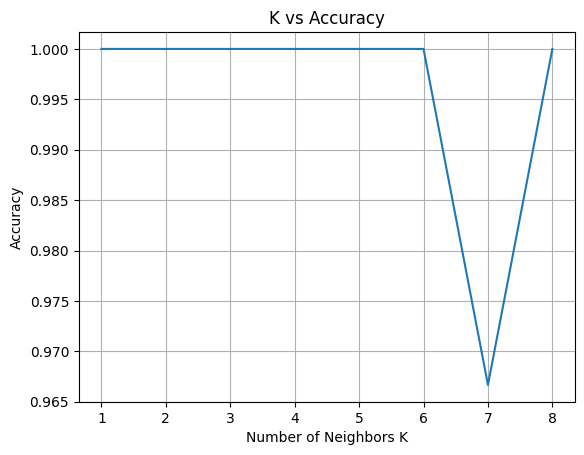

In [26]:
# lets find the k value
import matplotlib.pyplot as plt
import numpy as np

accuracy_values = []
k_values = range(1, 9)
print(k_values)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_values.append(accuracy)

plt.plot(k_values, accuracy_values)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.xticks(np.arange(1, 9, 1))
plt.grid()
plt.show()  

In [27]:
# lets we are happy with k=7
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with k=7: {accuracy}")

Accuracy with k=7: 0.9666666666666667


In [28]:
# lets save the model
import pickle
with open('knn_iris_model.pkl', 'wb') as f:
    pickle.dump(model, f)



In [30]:
#loads the model
with open('knn_iris_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
loaded_model.predict(single_value)

array([1])

In [31]:
# lets take knn regression
from sklearn.neighbors import KNeighborsRegressor


In [33]:
# lets take regression data
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# lets convert into dataframe
import pandas as pd
df_diabetes = pd.DataFrame(X_diabetes, columns=diabetes.feature_names)
df_diabetes['target'] = y_diabetes
df_diabetes.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [35]:
# lets apply knn regression
X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
# lets check the accuracy
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)   

Predictions: [125.6 160.2 153.  238.  153.4 150.4 246.2 170.  106.6 104.6  93.2 151.6
 104.  166.6  61.4 105.4 263.8 252.  173.6 215.4 184.6  86.6 106.6 174.
 158.2 168.  196.6 145.6  67.6 117.2 158.  166.6  89.  158.4 166.4 243.6
  73.8 136.8 148.6 106.6  90.  100.6 134.2 147.6 193.4  81.6  83.6  90.8
  84.4 119.2 117.8  88.2 150.6 112.  210.2 130.8  79.4 175.8 120.4  73.
 155.  117.6  58.   94.6 169.4 187.4 214.4 146.4 145.2 118.8 119.2 195.
 204.4  98.6 107.8 209.4 151.  163.6 210.4 218.2 150.8 139.   67.4  82.4
 105.4 113.2 110.4  84.2 159.2]
Mean Squared Error: 3019.075505617978


In [36]:
# ltes create the copy of the test data
df_test_diabetes= X_test.copy()
df_test_diabetes = pd.DataFrame(df_test_diabetes, columns=diabetes.feature_names)
df_test_diabetes['predicted_target'] = y_pred
df_test_diabetes['actual_target'] = y_test
df_test_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,predicted_target,actual_target
0,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220,125.6,219.0
1,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,160.2,70.0
2,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,153.0,202.0
3,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,238.0,230.0
4,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362,153.4,111.0


In [37]:
# save the model
# lets save the model
import pickle
with open('knn_diabetes_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [1]:
# lets add two list
list1 = [1, 2, 3]
list2 = [4, 5, 6]
combined_list = list1 + list2
print("Combined List:", combined_list)


Combined List: [1, 2, 3, 4, 5, 6]


In [ ]:
# lets train the KNN model with k=3
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

_IncompleteInputError: incomplete input (771999960.py, line 6)

## Classification algorithm in various  situation

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [5]:
# lets bring imbalance dataset
from sklearn.datasets import make_classification
X_imb, y_imb = make_classification(n_samples=1000, n_features=10, n_classes=2,
                                   n_informative=2, n_redundant=2,
                                   weights=[0.9, 0.1], flip_y=0,
                                   random_state=42)

# lets convert into dataframe
import pandas as pd
df_imb = pd.DataFrame(X_imb, columns=[f'feature_{i}' for i in range(10)])
df_imb['target'] = y_imb

df_imb.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,-2.619427,-0.190039,2.023606,-1.607661,-1.473127,1.688159,1.750412,0.184741,-0.357445,0.006800,0
1,-1.106788,1.257619,0.505735,1.671348,0.739829,0.448673,0.181863,-0.901376,0.406056,-0.086701,0
2,-0.721330,0.134166,-2.384307,0.082773,-0.937254,0.568143,0.699666,0.036783,0.428342,0.745151,0
3,-0.471095,-1.372859,1.194763,-0.985804,-0.893229,0.425658,0.572040,-0.284155,0.351480,0.894647,0
4,-0.950992,-0.766045,0.784146,-1.383341,0.639499,0.384776,0.154703,0.901729,-0.461267,-0.898027,0


In [6]:
df_imb['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

In [12]:
# lets do the experiment without handling imbalance data
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.925


In [13]:
# lets make data balanced using oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_imb, y_imb)
X_resampled.shape, y_resampled.shape


((1800, 10), (1800,))

In [ ]:
# lets train the KNN model with k=5
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_resampled, y_resampled)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# assignment
# note down your observations
# 1. The accuracy of the model before oversampling was lower compared to after oversampling.
# 2. Oversampling helped in balancing the dataset, which in turn improved the model's performance.
# 3. The KNN model is sensitive to the distribution of the training data, and balancing the classes can lead to better generalization.


Accuracy: 0.96


In [15]:
# lets create multi class imbalance datafrom sklearn.datasets import make_classification
X_multi, y_multi = make_classification(n_samples=1000, n_features=10, n_classes=3,
                                       n_informative=5, n_redundant=2,
                                       weights=[0.7, 0.2, 0.1], flip_y=0,
                                       random_state=42)
# lets convert into dataframe
df_multi = pd.DataFrame(X_multi, columns=[f'feature_{i}' for i in range(10)])
df_multi['target'] = y_multi
df_multi.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,-2.403709,2.540391,1.640905,-0.631065,0.590005,-1.558103,0.369081,0.068350,-2.100106,2.486643,2
1,1.239891,-3.071151,1.539799,-1.151847,-0.396210,0.836711,-0.372971,0.777972,0.487397,-0.265937,0
2,1.223381,1.480886,-2.141814,-2.620514,-0.934154,-0.088952,-5.594458,-1.511787,-1.334947,-2.584707,0
3,1.589582,0.264271,0.018181,-1.361425,-0.278709,0.761348,-0.784114,-0.774462,1.985939,-2.308325,1
4,-0.599860,0.706485,2.412654,-1.174364,-0.422210,-2.762916,-0.254527,1.118183,-1.556218,0.423009,0


In [16]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.87


In [27]:
# lets test for single value
single_value = X_test[44].reshape(1, -1)
print("Single value input:", single_value)
single_pred = model.predict(single_value)
print("Single value prediction:", single_pred)  

Single value input: [[-1.22244734 -0.74385939  0.50196386 -1.25397272  1.02861031 -2.86481422
  -2.08384904 -1.14734152 -2.67444724  0.27109328]]
Single value prediction: [0]


In [28]:
# time based splitting
# lets create time series data
import numpy as np
date_range = pd.date_range(start='1/1/2020', periods=100, freq='D')
X_time = np.random.rand(100, 5)
y_time = np.random.randint(0, 2, size=100)
df_time = pd.DataFrame(X_time, columns=[f'feature_{i}' for i in range(5)])
df_time['target'] = y_time
df_time['date'] = date_range
df_time.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target,date
0,0.898646,0.691309,0.462013,0.491881,0.660779,0,2020-01-01
1,0.910391,0.638347,0.126248,0.702328,0.036446,0,2020-01-02
2,0.306690,0.260969,0.059632,0.252609,0.318589,0,2020-01-03
3,0.940712,0.660467,0.635162,0.253122,0.792930,0,2020-01-04
4,0.102787,0.203195,0.322741,0.300537,0.987253,1,2020-01-05


In [29]:
# time based splitting
df_time = df_time.sort_values(by='date')
split_date = '2020-03-15'
train_data = df_time[df_time['date'] < split_date]
test_data = df_time[df_time['date'] >= split_date]

X_train = train_data.drop(columns=['target', 'date'])
y_train = train_data['target']
X_test = test_data.drop(columns=['target', 'date'])
y_test = test_data['target']

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5384615384615384


In [30]:
# assignment
# Do experiments with different values of k and note down your observations.
# Create a balanced multi-class dataset and evaluate the KNN model on it.
# Implement time-based splitting on a different time series dataset and evaluate the KNN model.
# Try with undersampling techniques and compare the results with oversampling.

In [31]:
# feature importance using KNN
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y    
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Accuracy: 1.0
Feature Importance:
 petal length (cm)    0.61
petal width (cm)     0.20
sepal length (cm)    0.01
sepal width (cm)     0.01
dtype: float64


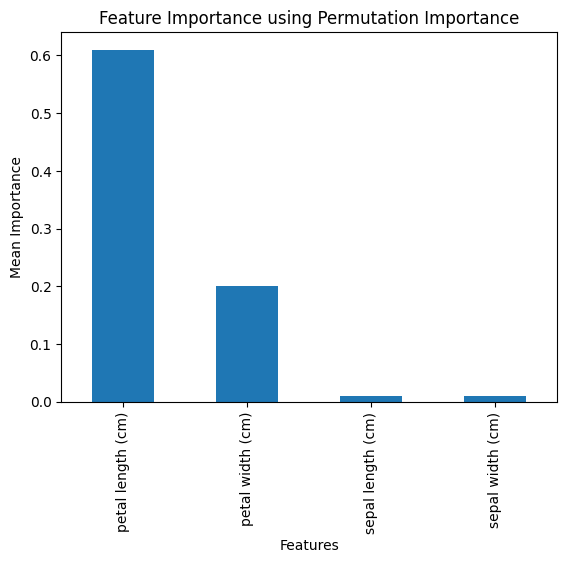

In [34]:
# lets split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# feature importance using permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame(result.importances.T, columns=data.feature_names)
importance_df_mean = importance_df.mean().sort_values(ascending=False)
print("Feature Importance:\n", importance_df_mean)

# lets plot the feature importance
import matplotlib.pyplot as plt
importance_df_mean.plot(kind='bar')
plt.title('Feature Importance using Permutation Importance')
plt.ylabel('Mean Importance')
plt.xlabel('Features')
plt.show()


In [ ]:
# Add reference links
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier
# https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html
# https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_import
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
# https://scikit-learn.org/stable/modules/permutation_importance.html
# https://junaidsqazi.medium.com/a37-importance-of-feature-scaling-in-knn-hands-on-implementation-cabfbb0cb62e


### Categorical columns

In [3]:
# lets create some data with categorycal features
import numpy as np
import pandas as pd
# weight hair color and height : create 1000 records
data = {'weight': np.random.randint(150, 200, 1000),
        'hair_color': np.random.choice(['black', 'brown', 'blonde'], 1000),
        'height': np.random.uniform(5.5, 6.0, 1000)
}
df = pd.DataFrame(data)
df.head()

,weight,hair_color,height
0,170,black,5.942269
1,150,brown,5.555894
2,189,blonde,5.932783
3,157,blonde,5.515593
4,170,blonde,5.708664


In [5]:
# one hot encoding
df_encoded = pd.get_dummies(df, columns=['hair_color'])
df_encoded.head()

,weight,height,hair_color_black,hair_color_blonde,hair_color_brown
0,170,5.942269,True,False,False
1,150,5.555894,False,False,True
2,189,5.932783,False,True,False
3,157,5.515593,False,True,False
4,170,5.708664,False,True,False


In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [12]:
# split the data
X = df_encoded.drop(columns=['height'])
y = df_encoded['height']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
model.predict(X_test)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.020970096524322263


In [14]:
# lets test for single value
single_value = np.array([[160, 0, 1, 0]])  # weight=160, hair_color=brown
print("Single value input:", single_value)
single_pred = model.predict(single_value)
print("Single value prediction:", single_pred)

Single value input: [[160   0   1   0]]
Single value prediction: [5.67194599]


/Users/rahultiwari/Documents/02_Freelancing/rbyte_ai_engineering/ai-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [17]:
# sklearn onehot encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
X_categorical = df[['hair_color']]
X_encoded = encoder.fit_transform(X_categorical)

# lets add the weight column
X_final = np.hstack((df[['weight']].values, X_encoded))

# lets train the model again
X_train, X_test, y_train, y_test = train_test_split(X_final, df['height'], test_size=0.2, random_state=42)
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error with sklearn OneHotEncoder:", mse)    

Mean Squared Error with sklearn OneHotEncoder: 0.020970096524322263


In [ ]:
# lets talk about missing value imputation
# lets create some data with missing values
import numpy as np
import pandas as pd
date_range = pd.date_range(start='1/1/2020', periods=100, freq='D')
X_time = np.random.rand(100, 5)
y_time = np.random.randint(0, 2, size=100)
df_time = pd.DataFrame(X_time, columns=[f'feature_{i}' for i in range(5)])
df_time['target'] = y_time
df_time['date'] = date_range
# introduce missing values
for col in df_time.columns[:-2]:  # exclude 'target' and 'date'
    df_time.loc[df_time.sample(frac=0.1).index, col] = np.nan
df_time.head()



,feature_0,feature_1,feature_2,feature_3,feature_4,target,date
0,0.889495,0.553861,0.779802,0.446317,0.334313,1,2020-01-01
1,0.372592,0.163354,0.108134,0.459574,NaN,1,2020-01-02
2,0.722103,0.488191,0.760297,0.873222,0.302648,1,2020-01-03
3,0.558350,0.895747,0.217952,0.292989,0.088518,0,2020-01-04
4,0.436183,0.301053,0.529636,NaN,0.584878,1,2020-01-05


In [21]:
df_time[df_time.isnull()]

,feature_0,feature_1,feature_2,feature_3,feature_4,target,date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,NaN,NaN,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...
95,NaN,NaN,NaN,NaN,NaN,NaN,NaT
96,NaN,NaN,NaN,NaN,NaN,NaN,NaT
97,NaN,NaN,NaN,NaN,NaN,NaN,NaT
98,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [22]:
# lets fill missing values with mean imputation
df_filled = df_time.fillna(df_time.mean())
df_filled.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target,date
0,0.889495,0.553861,0.779802,0.446317,0.334313,1,2020-01-01
1,0.372592,0.163354,0.108134,0.459574,0.481190,1,2020-01-02
2,0.722103,0.488191,0.760297,0.873222,0.302648,1,2020-01-03
3,0.558350,0.895747,0.217952,0.292989,0.088518,0,2020-01-04
4,0.436183,0.301053,0.529636,0.534577,0.584878,1,2020-01-05


In [23]:
df_filled.isnull().sum()

feature_0    0
feature_1    0
feature_2    0
feature_3    0
feature_4    0
target       0
date         0
dtype: int64

In [24]:
# lets create retail data to predict will custome buy the products or not ( category column, misisng values, numerical columns)
import numpy as np
import pandas as pd
date_range = pd.date_range(start='1/1/2020', periods=1000, freq='D')
data = {
    'age': np.random.randint(18, 70, 5000),
    'income': np.random.randint(30000, 100000, 5000),
    'category': np.random.choice(['A', 'B', 'C'], 5000),
    'last_purchase_date': np.random.choice(date_range, 5000),
    'total_spent': np.random.uniform(100, 10000, 5000),
    'last_login_date': np.random.choice(date_range, 5000),
    'purchase_frequency': np.random.randint(1, 20, 5000),
    'digital_engagement_score': np.random.uniform(0, 100, 5000),
    'purchase': np.random.choice([0, 1], 5000),

}

df = pd.DataFrame(data)
df.head(2)

,age,income,category,last_purchase_date,total_spent,last_login_date,purchase_frequency,digital_engagement_score,purchase
0,44,83796,A,2021-03-20,4817.378008,2022-05-20,19,18.070158,0
1,47,30075,A,2020-10-17,2139.637167,2020-10-13,4,87.568482,0


In [ ]:
# Task 
# Understand the data and preprocess it (handle categorical features, missing values, etc.)
# Split the data into training and testing sets using time-based splitting.
# Train a KNN model to predict whether a customer will buy a product or not. # ecludian distance, manhattan distance, minkowski distance
# Evaluate the model's performance using appropriate metrics.
# Experiment with different values of k and note down your xobservations.
# Handle any missing values( mean , median, mode) in the dataset and observe how it affects the model's performance.